In [1]:
import numpy as np 
import pandas as pd 

preprocess_dir = f"../data_analysis1/artifacts/preprocess"
models_dir = f"../data_analysis1/artifacts/models"

X = np.load(f"{preprocess_dir}/data_matrix1.npy")
X_reduced = np.load(f"{preprocess_dir}/data_matrix_reduced.npy")
X_reduced_1 = np.load(f"{preprocess_dir}/data_matrix_reduced1.npy")

y = np.load(f"{preprocess_dir}/y.npy")

import joblib
import json

drop_cols = joblib.load(f"{preprocess_dir}/data_matrix_drop_cols.joblib")

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping

d:\Deep Learning Projects\Deep CSAT - Ecommerce Customer Satisfaction Score Prediction\csat_venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
d:\Deep Learning Projects\Deep CSAT - Ecommerce Customer Satisfaction Score Prediction\csat_venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
d:\Deep Learning Projects\Deep CSAT - Ecommerce Customer Satisfaction Score Prediction\csat_venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning:

In [3]:
X.shape , X_reduced.shape , X_reduced_1.shape

((85849, 139), (85849, 131), (85849, 65))

In [4]:
y.shape

(85849,)

In [6]:
np.unique(y,return_counts=True)

(array([1, 2, 3, 4, 5]), array([11213,  1282,  2557, 11210, 59587]))

In [8]:
drop_cols

{'corr_drop_cols': [0, 2, 4, 18, 20, 21, 23, 27],
 'vif_drop_cols': array([  0,   2,   3,   4,   5,   6,   9,  10,  11,  12,  13,  18,  19,
         20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  33,
         34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,
         47,  48,  49,  50,  51,  52,  53,  55,  57,  58,  59,  60,  61,
         62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,
         75,  79,  80,  83,  84,  85,  86, 135, 136])}

In [9]:
drop_cols_1 = drop_cols["corr_drop_cols"]
drop_cols_2 = drop_cols["vif_drop_cols"]


In [7]:
import warnings 
warnings.filterwarnings('ignore')

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Input,Dense, Dropout, BatchNormalization, Flatten 
from tensorflow.keras.utils import to_categorical 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Accuracy , Precision , Recall,AUC


In [11]:
len(drop_cols_1), len(drop_cols_2)

(8, 74)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [13]:
np.unique(y , return_counts=True)

(array([1, 2, 3, 4, 5]), array([11213,  1282,  2557, 11210, 59587]))

In [14]:
import json 
with open(f'{preprocess_dir}/class_weights.json','r') as file:
    class_weights = json.load(file)


print(class_weights)

{'5': 1.44, '1': 7.65, '4': 7.66, '3': 33.58, '2': 66.96}


In [15]:
xtrain ,  xtest ,ytrain ,ytest = train_test_split(X , y , test_size = 0.1 , stratify = y , random_state=42)
xtrain.shape , ytrain.shape , xtest.shape , ytest.shape

((77264, 139), (77264,), (8585, 139), (8585,))

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np





def evaluate_classification_model1(model, X_train, y_train, X_test, y_test):
    """ This function evaluates a classification model using macro averaging for metrics whereever applicable."""
    
    results = {}

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities for ROC AUC if available (multiclass classification)
    y_train_prob = model.predict_proba(X_train) if hasattr(model, "predict_proba") else None
    y_test_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    # Calculate metrics helper - Macro averaging for multiclass classification because of class imbalance - to give equal importance to all classes
    def calc_metrics(y_true, y_pred, y_prob=None):
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0, average='macro')
        recall = recall_score(y_true, y_pred, zero_division=0, average='macro')
        f1 = f1_score(y_true, y_pred, zero_division=0, average='macro')
        roc_auc = (
            roc_auc_score(y_true, y_prob, average='macro', multi_class='ovr')
            if y_prob is not None
            else None
        )
        return accuracy, precision, recall, f1, roc_auc

    train_metrics = calc_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics = calc_metrics(y_test, y_test_pred, y_test_prob)

    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

    # Print metrics
    print("Training Metrics:")
    for name, value in zip(metric_names, train_metrics):
        if value is not None:
            print(f"{name}: {value:.4f}")

    print("\nTesting Metrics:")
    for name, value in zip(metric_names, test_metrics):
        if value is not None:
            print(f"{name}: {value:.4f}")

    # Detailed classification report for test
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # Confusion matrix plot for test data
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Plot ROC curves per class for multiclass data (One-vs-Rest)
    if y_test_prob is not None:
        classes = np.unique(y_test)
        y_test_binarized = label_binarize(y_test, classes=classes)
        n_classes = y_test_binarized.shape[1]

        plt.figure(figsize=(8, 6))

        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_test_prob[:, i])
            roc_auc = roc_auc_score(y_test_binarized[:, i], y_test_prob[:, i])
            plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

        plt.plot([0, 1], [0, 1], "k--", label="Random Chance")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Multiclass ROC Curve (One-vs-Rest)")
        plt.legend()
        plt.grid(True)
        plt.show()

    return {"train_metrics": train_metrics, "test_metrics": test_metrics}


In [15]:
lr = LogisticRegression(random_state = 42 , verbose = 1 , n_jobs=-1)
lr.fit(xtrain,ytrain)

print(lr.score(xtrain,ytrain))
print(lr.score(xtest,ytest))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


0.7173716090287844
0.718345952242283


Training Metrics:
Accuracy: 0.7174
Precision: 0.2755
Recall: 0.2496
F1 Score: 0.2417
ROC AUC: 0.6784

Testing Metrics:
Accuracy: 0.7183
Precision: 0.2779
Recall: 0.2516
F1 Score: 0.2443
ROC AUC: 0.6762

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.67      0.27      0.39      1121
           2       0.00      0.00      0.00       128
           3       0.00      0.00      0.00       256
           4       0.00      0.00      0.00      1121
           5       0.72      0.98      0.83      5959

    accuracy                           0.72      8585
   macro avg       0.28      0.25      0.24      8585
weighted avg       0.59      0.72      0.63      8585



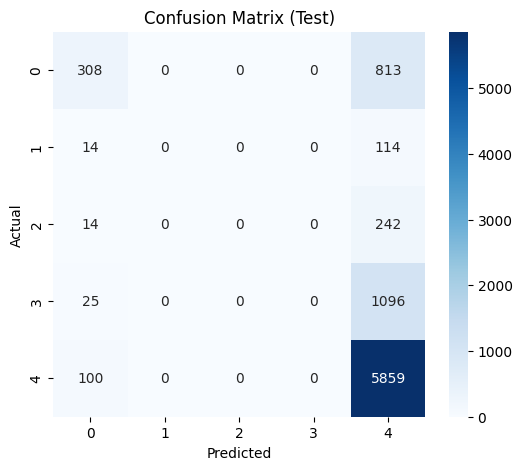

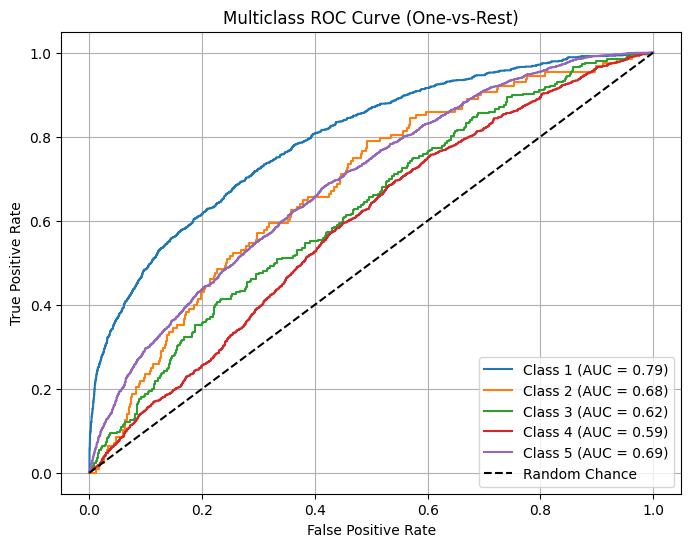

In [16]:
lr_train_metrics, lr_test_metrics = evaluate_classification_model1(lr, xtrain, ytrain, xtest, ytest)

We can see that Accuracy is 71% which means 71% records are being correctly predicted by the Model.However it is to note that the target classes are highly imbalanced. So accuracy is not a very powerful signal for good model performance. It might be just correctly predicting the majority which completely failing in the minority classes and even then it will be having a high accuracy.

Precision is very low indicating high false positives. For multiclass classification it means the high false positives on average for all the classes.
Similarly low recall means high False Negatives.

Classification Report for test data shows that model is giving good precision and recall for Class 5 comparatively. Class 5 is the majority class of all. For this class low false positives and very low false negatives. But of the class 2,3,4 the scores of all metrics are 0 - the model is completely avoiding to predict these clases. TP = 0 for all these classes.


In [17]:

lr1 = LogisticRegression(max_iter=1000 , random_state = 42 , n_jobs=-1 )
lr1.fit(xtrain,ytrain)

print(lr1.score(xtrain,ytrain))
print(lr1.score(xtest,ytest))

0.7173327811141023
0.7182294700058242


Training Metrics:
Accuracy: 0.7173
Precision: 0.2751
Recall: 0.2496
F1 Score: 0.2417
ROC AUC: 0.6796

Testing Metrics:
Accuracy: 0.7182
Precision: 0.2770
Recall: 0.2516
F1 Score: 0.2441
ROC AUC: 0.6753

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.66      0.27      0.39      1121
           2       0.00      0.00      0.00       128
           3       0.00      0.00      0.00       256
           4       0.00      0.00      0.00      1121
           5       0.72      0.98      0.83      5959

    accuracy                           0.72      8585
   macro avg       0.28      0.25      0.24      8585
weighted avg       0.59      0.72      0.63      8585



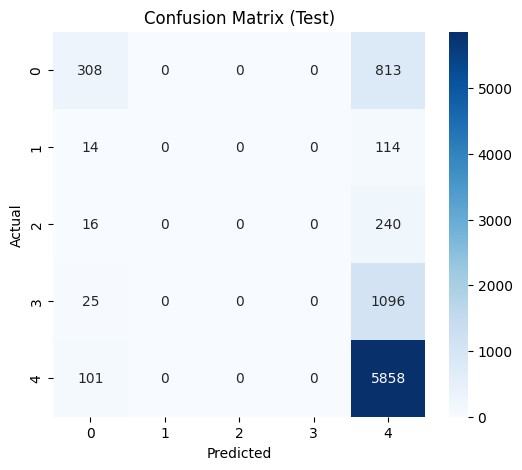

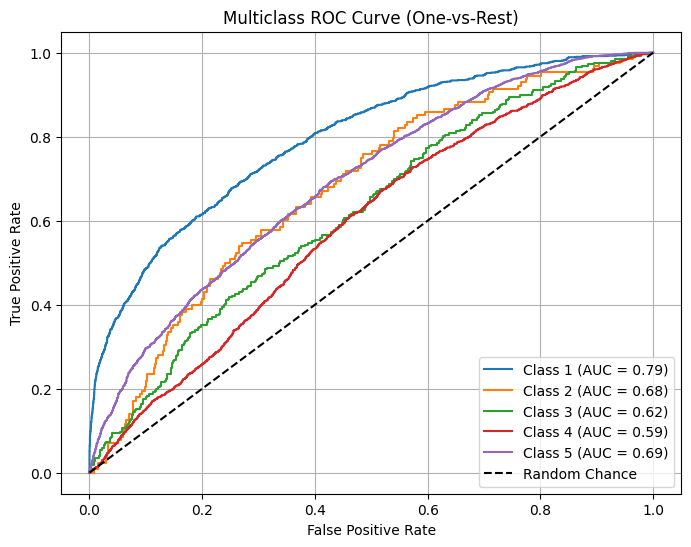

In [18]:
lr1_train_metrics, lr1_test_metrics = evaluate_classification_model1(lr1, xtrain, ytrain, xtest, ytest)

# Lower precision_score indicates higher cases of False Positives.Since it is multiclass classification , it indicates that some classes are being misclassified as other classes.


# Lower recall score indicates higher cases of False negatives.Since it is macro recall , it takes the arithmetic mean of all class recalls , treating all classes equally regardless of their frequency.Thereby the lower macro recall indicates that the model is giving higher number of false negatives across overall all classes.

# ROC AUC = 0.66 means that the model has a 66% chance of distinguishing between classes, which is better than random guessing but indicates room for improvement.This is macro roc : all classes ROC averaged.

# Classification report precision,recall , f1 are 0 for 2 , 3 , 4 indicates that the model is not predicting any instances of these classes correctly, likely due to class imbalance or insufficient training data for these classes.It indicates that TP = 0 for these classes. 
# Similarly recall is also 0 for these classes indicating that the model is not able to identify any actual instances of these classes correctly.
# Overall , the model performs well on the majority class (class 5) and the class 1 , but struggles with minority classes (2, 3, 4) likely due to class imbalance.



In [19]:
class_weights

{'5': 1.44, '1': 7.65, '4': 7.66, '3': 33.58, '2': 66.96}

In [20]:
class_weights_int = {int(key) : value for key , value in class_weights.items()}
class_weights_int

{5: 1.44, 1: 7.65, 4: 7.66, 3: 33.58, 2: 66.96}

In [ ]:
# Linear regression with class weights to handle class imbalance
lr2 = LogisticRegression(max_iter=1000 , class_weight='balanced', random_state=42)
lr2.fit(xtrain,ytrain)

print(lr2.score(xtrain,ytrain))
print(lr2.score(xtest,ytest))

0.37934872644439843
0.3804309842748981


Training Metrics:
Accuracy: 0.3793
Precision: 0.2915
Recall: 0.3297
F1 Score: 0.2578
ROC AUC: 0.6609

Testing Metrics:
Accuracy: 0.3804
Precision: 0.2910
Recall: 0.3237
F1 Score: 0.2571
ROC AUC: 0.6525

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.38      0.46      0.42      1121
           2       0.03      0.28      0.05       128
           3       0.05      0.19      0.07       256
           4       0.17      0.30      0.22      1121
           5       0.83      0.39      0.53      5959

    accuracy                           0.38      8585
   macro avg       0.29      0.32      0.26      8585
weighted avg       0.65      0.38      0.46      8585



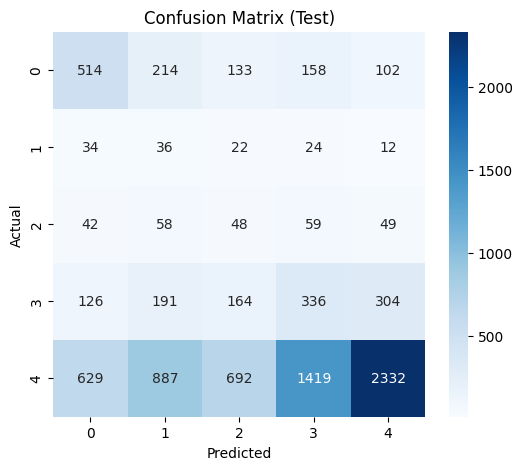

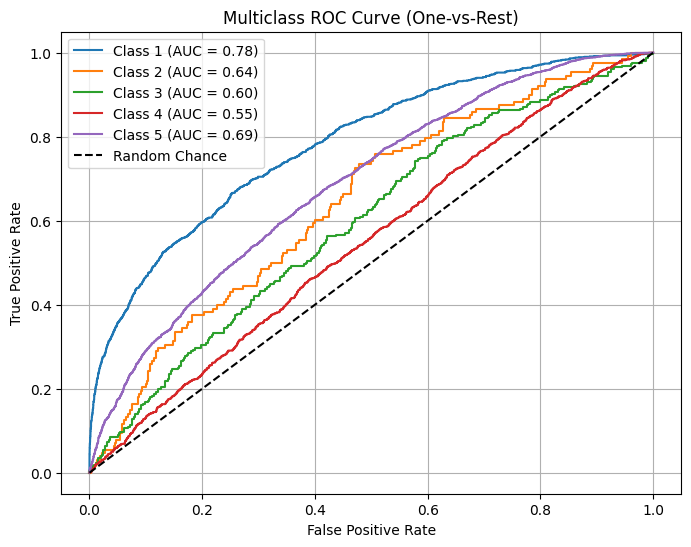

In [22]:
lr2_train_metrics, lr2_test_metrics = evaluate_classification_model1(lr2, xtrain, ytrain, xtest, ytest)

With the addition class weights, The minority class performance metrics had shown as slight improvement especially for class 4 but even then the performance is very low.

Also the recall had significantly reduced for the majority class 5 meaning higher False Negatives for the class. 

In [23]:
lr3 = LogisticRegression(max_iter=1000 , class_weight=class_weights_int, random_state=42)
lr3.fit(xtrain,ytrain)

print(lr3.score(xtrain,ytrain))
print(lr3.score(xtest,ytest))

0.37835214330089045
0.37938264414676764


Creating RF , XGB , DNN for this dataset 

In [24]:
rf1 = RandomForestClassifier(random_state = 42,n_jobs=-1 , n_estimators=200 , max_depth=10)

rf1.fit(xtrain,ytrain)

print(rf1.score(xtrain,ytrain))
print(rf1.score(xtest,ytest))

0.7157537792503624
0.7134536983110076


Training Metrics:
Accuracy: 0.7158
Precision: 0.3127
Recall: 0.2352
F1 Score: 0.2251
ROC AUC: 0.7543

Testing Metrics:
Accuracy: 0.7135
Precision: 0.3059
Recall: 0.2331
F1 Score: 0.2220
ROC AUC: 0.6780

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.82      0.17      0.28      1121
           2       0.00      0.00      0.00       128
           3       0.00      0.00      0.00       256
           4       0.00      0.00      0.00      1121
           5       0.71      1.00      0.83      5959

    accuracy                           0.71      8585
   macro avg       0.31      0.23      0.22      8585
weighted avg       0.60      0.71      0.61      8585



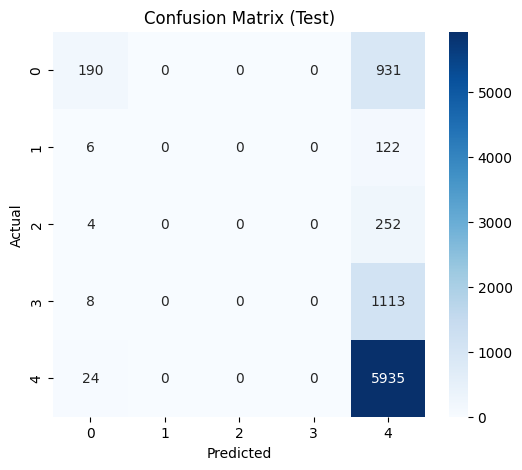

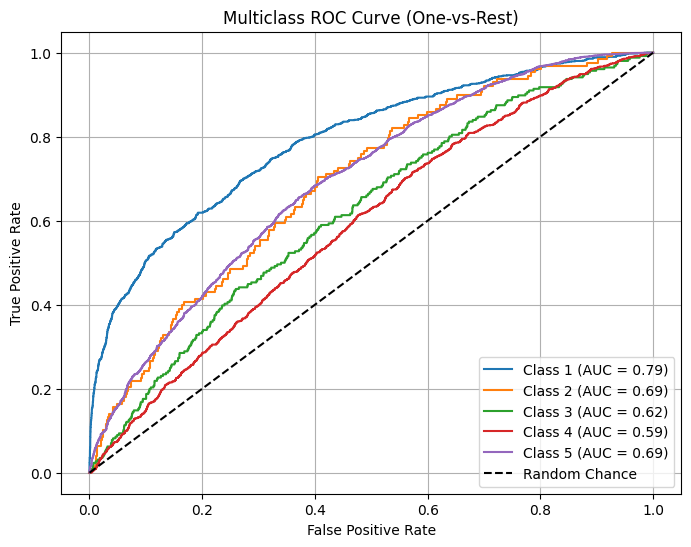

In [25]:
rf1_train_metrics, rf1_test_metrics = evaluate_classification_model1(rf1, xtrain , ytrain , xtest , ytest)

In [26]:
rf2 = RandomForestClassifier(random_state = 42,n_jobs=-1 , n_estimators=200 , max_depth=10 , class_weight='balanced')

rf2.fit(xtrain,ytrain)

print(rf2.score(xtrain,ytrain))
print(rf2.score(xtest,ytest))

0.44636570718575275
0.41094933022714036


Training Metrics:
Accuracy: 0.4464
Precision: 0.3370
Recall: 0.4614
F1 Score: 0.3315
ROC AUC: 0.7685

Testing Metrics:
Accuracy: 0.4109
Precision: 0.2861
Recall: 0.3033
F1 Score: 0.2612
ROC AUC: 0.6549

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.38      0.52      0.44      1121
           2       0.02      0.08      0.03       128
           3       0.04      0.14      0.06       256
           4       0.16      0.37      0.22      1121
           5       0.83      0.42      0.56      5959

    accuracy                           0.41      8585
   macro avg       0.29      0.30      0.26      8585
weighted avg       0.65      0.41      0.48      8585



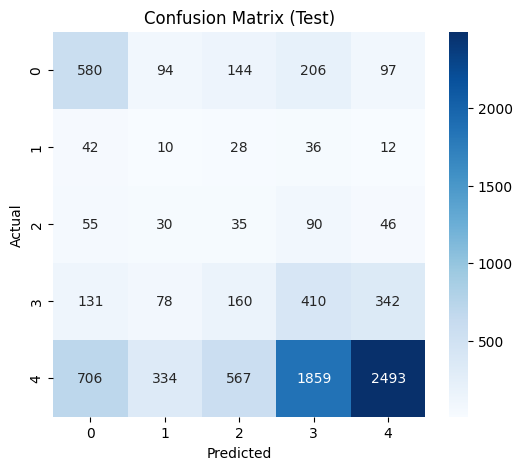

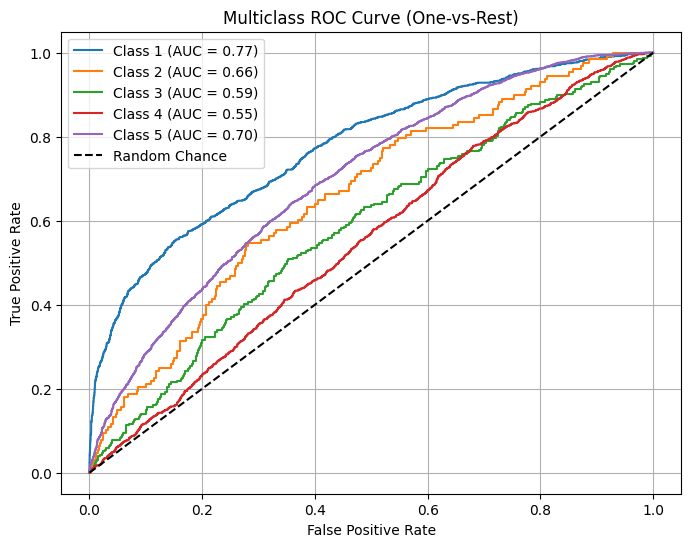

In [27]:
rf2_train_metrics, rf2_test_metrics=evaluate_classification_model1(rf2, xtrain , ytrain , xtest , ytest)

In [28]:
rf3 = RandomForestClassifier(random_state = 42,n_jobs=-1 , n_estimators=200 , max_depth=20 , class_weight="balanced")

rf3.fit(xtrain,ytrain)

print(rf3.score(xtrain,ytrain))
print(rf3.score(xtest,ytest))

0.883218575274384
0.6283051834595225


Training Metrics:
Accuracy: 0.8832
Precision: 0.7863
Recall: 0.8761
F1 Score: 0.8252
ROC AUC: 0.9620

Testing Metrics:
Accuracy: 0.6283
Precision: 0.2899
Recall: 0.2887
F1 Score: 0.2887
ROC AUC: 0.6463

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.46      0.46      0.46      1121
           2       0.02      0.01      0.01       128
           3       0.05      0.04      0.04       256
           4       0.16      0.14      0.15      1121
           5       0.76      0.79      0.77      5959

    accuracy                           0.63      8585
   macro avg       0.29      0.29      0.29      8585
weighted avg       0.61      0.63      0.62      8585



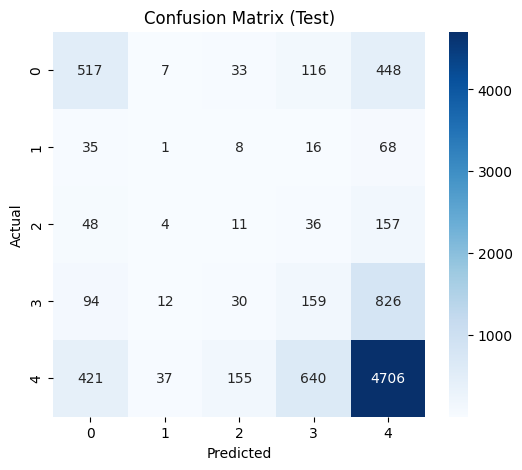

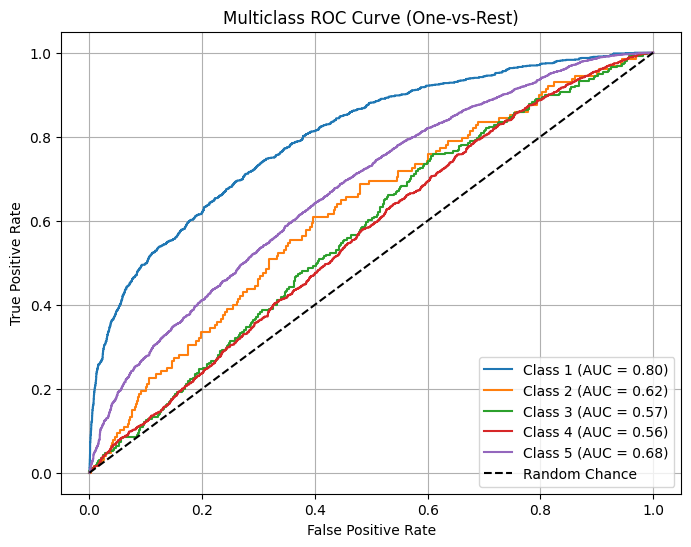

In [29]:
rf3_train_metrics, rf3_test_metrics = evaluate_classification_model1(rf3, xtrain, ytrain, xtest, ytest)

In [30]:
class_weights_int_xgb = {key-1 : value for key, value in class_weights_int.items()}
class_weights_int_xgb

{4: 1.44, 0: 7.65, 3: 7.66, 2: 33.58, 1: 66.96}

In [31]:
# Trying XGB

classes = np.unique(y)-1
sample_weights = np.array([class_weights_int_xgb[label] for label in ytrain-1])


xgb1 = XGBClassifier(random_state=42,objective = 'multi:softmax' )
xgb1.fit(xtrain, ytrain-1, sample_weight=sample_weights)


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
xgb1.score(xtrain,ytrain-1) , xgb1.score(xtest,ytest-1)

(0.5424000828328847, 0.438905066977286)

Training Metrics:
Accuracy: 0.5424
Precision: 0.4042
Recall: 0.6415
F1 Score: 0.4260
ROC AUC: 0.8553

Testing Metrics:
Accuracy: 0.4389
Precision: 0.2871
Recall: 0.3180
F1 Score: 0.2730
ROC AUC: 0.6472

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.39      0.49      0.44      1121
           1       0.03      0.13      0.04       128
           2       0.05      0.21      0.09       256
           3       0.15      0.28      0.20      1121
           4       0.81      0.47      0.60      5959

    accuracy                           0.44      8585
   macro avg       0.29      0.32      0.27      8585
weighted avg       0.63      0.44      0.50      8585



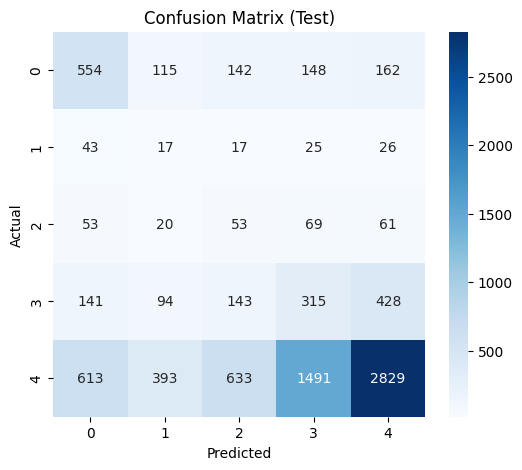

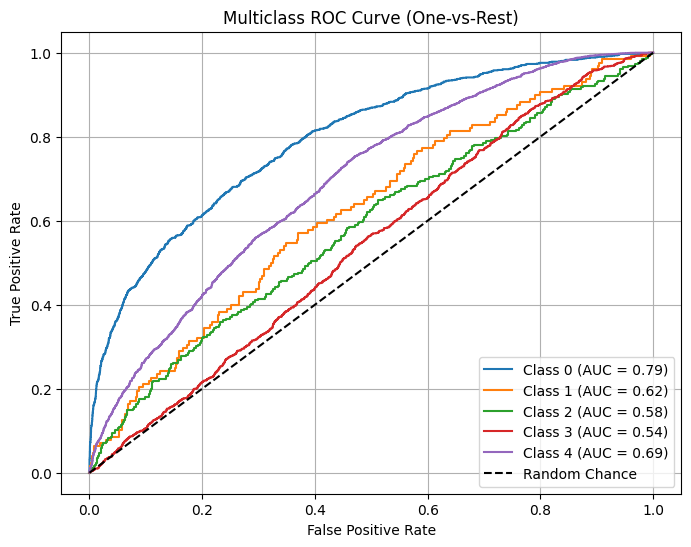

In [33]:
xgb1_train_metrics, xgb1_test_metrics=evaluate_classification_model1(xgb1, xtrain, ytrain-1, xtest, ytest-1)

In [34]:
xgb2 = XGBClassifier(random_state=42,
         n_estimators = 200,
         max_depth = 20,
         learning_rate = 0.1,
         objective = 'multi:softmax' )
xgb2.fit(xtrain, ytrain-1, sample_weight=sample_weights)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [35]:
xgb2.score(xtrain,ytrain-1) , xgb2.score(xtest,ytest-1)

(0.9995599503002692, 0.6767617938264414)

Training Metrics:
Accuracy: 0.9996
Precision: 0.9990
Recall: 0.9999
F1 Score: 0.9995
ROC AUC: 1.0000

Testing Metrics:
Accuracy: 0.6768
Precision: 0.2954
Recall: 0.2713
F1 Score: 0.2694
ROC AUC: 0.6326

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.50      0.40      0.44      1121
           1       0.00      0.00      0.00       128
           2       0.12      0.01      0.02       256
           3       0.13      0.05      0.07      1121
           4       0.74      0.89      0.81      5959

    accuracy                           0.68      8585
   macro avg       0.30      0.27      0.27      8585
weighted avg       0.60      0.68      0.63      8585



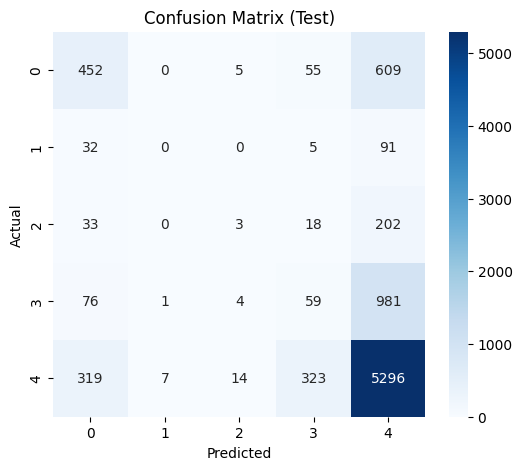

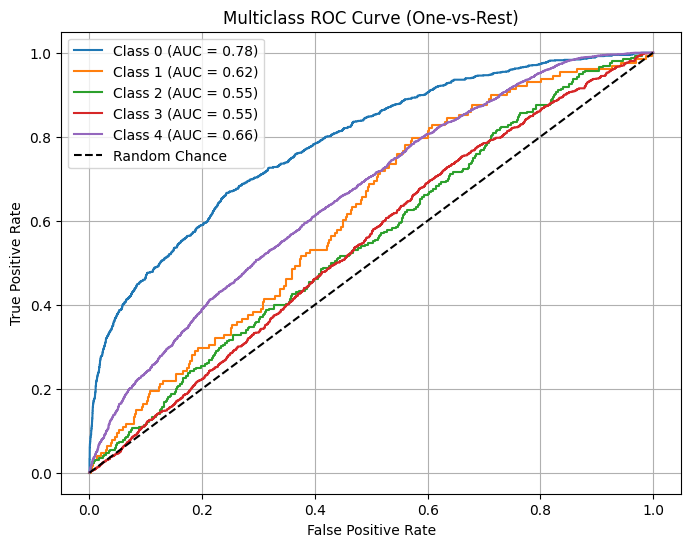

In [36]:
xgb2_train_metrics, xgb2_test_metrics=evaluate_classification_model1(xgb2, xtrain, ytrain-1, xtest, ytest-1)

Now trying ann models

In [37]:
import tensorflow as tf
tf.__version__

'2.20.0-rc0'

In [38]:
classes = np.unique(y)-1
n_classes = len(classes)

In [39]:

# Model creation
ann1 = Sequential()
ann1.add(Input(shape=(xtrain.shape[1],)))
ann1.add(Dense(128, activation='relu',))
ann1.add(Dense(64 , activation = 'relu'))
ann1.add(Dense(n_classes , activation = 'softmax') )

ann1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,501 (103.52 KB)

 Trainable params: 26,501 (103.52 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Model_compilation



ann1.compile(optimizer=Adam(learning_rate=0.1), 
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])

In [41]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5 , mode = 'min' , min_lr = 0.0001)

early_stop = EarlyStopping(monitor= 'val_loss',
                           patience = 20,
                           verbose = 1 ,
                           mode = 'min' ,
                           restore_best_weights = True)


In [42]:
# Fit the model 

history = ann1.fit(xtrain, ytrain-1,
                   validation_data=(xtest, ytest-1), epochs=100, 
                   batch_size=32,
             callbacks = [reduce_lr , early_stop])    

Epoch 1/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6932 - loss: 0.9820 - val_accuracy: 0.6940 - val_loss: 0.9378 - learning_rate: 0.1000
Epoch 2/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6940 - loss: 0.9570 - val_accuracy: 0.6941 - val_loss: 0.9437 - learning_rate: 0.1000
Epoch 3/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6939 - loss: 0.9589 - val_accuracy: 0.6941 - val_loss: 0.9535 - learning_rate: 0.1000
Epoch 4/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6941 - loss: 0.9589 - val_accuracy: 0.6941 - val_loss: 0.9567 - learning_rate: 0.1000
Epoch 5/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6941 - loss: 0.9605 - val_accuracy: 0.6941 - val_loss: 0.9629 - learning_rate: 0.1000
Epoch 6/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6941 - loss: 0.9587 - val_accuracy: 0.6941 - val_loss: 0.9560 - learning_rate: 0.1000
Epoch 7/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6

In [43]:

# Plot Loss

def performance_plots(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy (or another metric you used, e.g. precision)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()



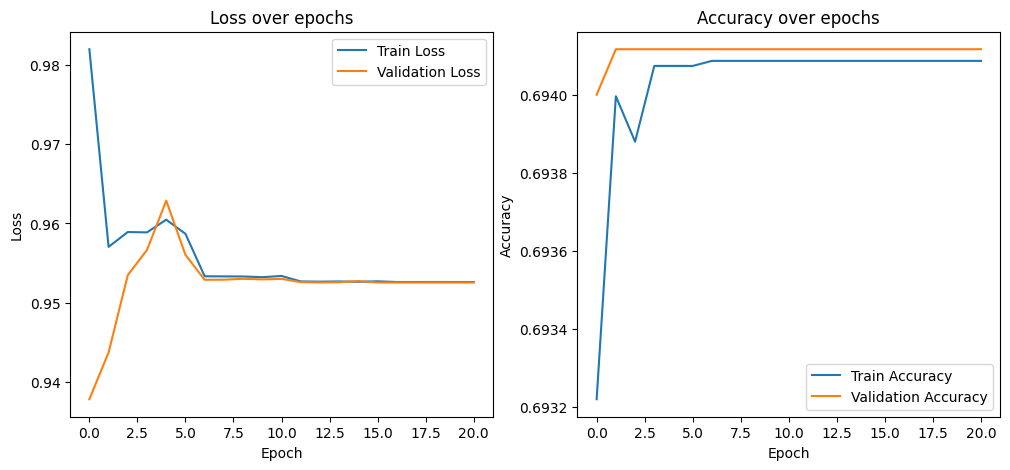

In [44]:

performance_plots(history)

The graphs shows that the model reached its peak performance quite early in the epochs and thereafter no further improvement happened on loss decrease and accuracy increase . The accuracy became stagnant at 0.6941 for both training and validation sets . The models shows not overfitting.

In [45]:
# from sklearn.metrics import f1_score
# import numpy as np
def metrics_eval(model, X_test, y_test):
   
    y_pred_prob = model.predict(X_test)  # shape: (n_samples, n_classes)
    y_pred = np.argmax(y_pred_prob, axis=1)  # class with highest probability

    f1 = f1_score(y_test, y_pred, average='macro')  # or 'weighted', 'micro' based on your needs
    print(f"F1 Score : {f1:.4f}")

    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")


In [46]:

metrics_eval(ann1, xtest, ytest-1)



269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step
F1 Score : 0.1639
Precision: 0.1388
Recall: 0.2000


ANN model2 : Making it more deeper and there complex that may be able to capture more underlying patterns in the data to reduce the bias occuring in the model training

In [47]:
# Model creation

ann2 = Sequential()
ann2.add(Input(shape=(xtrain.shape[1],)))
ann2.add(Dense(256, activation='relu',))
ann2.add(Dense(128, activation='relu',))
ann2.add(Dense(64 , activation = 'relu'))
ann2.add(Dense(n_classes , activation = 'softmax') )

ann2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,317 (302.02 KB)

 Trainable params: 77,317 (302.02 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Model_compilation

ann2.compile(optimizer=Adam(learning_rate=0.1), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])


In [49]:

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3 , mode = 'min' , min_lr = 0.0001)

early_stop = EarlyStopping(monitor= 'val_loss',
                           patience = 6,
                           verbose = 1 ,
                           mode = 'min' ,
                           restore_best_weights = True)

# Fit the model 

history1 = ann1.fit(xtrain, ytrain-1, validation_data=(xtest, ytest-1), epochs=50, batch_size=32,
                    callbacks = [reduce_lr , early_stop])    





Epoch 1/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6941 - loss: 0.9374 - val_accuracy: 0.6940 - val_loss: 0.9356 - learning_rate: 1.0000e-04
Epoch 2/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6941 - loss: 0.9362 - val_accuracy: 0.6940 - val_loss: 0.9350 - learning_rate: 1.0000e-04
Epoch 3/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6941 - loss: 0.9357 - val_accuracy: 0.6940 - val_loss: 0.9348 - learning_rate: 1.0000e-04
Epoch 4/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6941 - loss: 0.9354 - val_accuracy: 0.6941 - val_loss: 0.9346 - learning_rate: 1.0000e-04
Epoch 5/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6941 - loss: 0.9351 - val_accuracy: 0.6941 - val_loss: 0.9345 - learning_rate: 1.0000e-04
Epoch 6/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6941 - loss: 0.9349 - val_accuracy: 0.6941 - val_loss: 0.9344 - learning_rate: 1.0000e-04
Epoch 7/50
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/ste

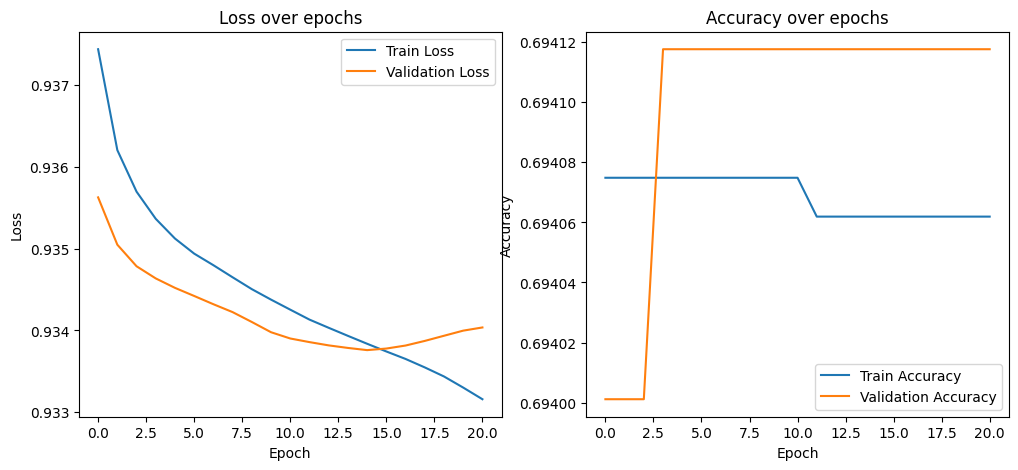

In [50]:
performance_plots(history1)

In [51]:
#Evaluate metrics : Precision , Recall , F1 score 

metrics_eval(ann2, xtest, ytest-1)

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step
F1 Score : 0.0927
Precision: 0.2005
Recall: 0.2018


Turning the multi class classification problem to binary classification (satisfied or not satisfied customers)

In [52]:
# y binarized

def binarize(y):
    return np.where(y >= 3, 1, 0)


# y_binarized = binarize(y)

In [53]:
ytrain_binarized = binarize(ytrain)
ytest_binarized = binarize(ytest)

print(np.unique(ytrain_binarized , return_counts= True))

print(np.unique(ytest_binarized , return_counts= True))

(array([0, 1]), array([11246, 66018]))
(array([0, 1]), array([1249, 7336]))


After binarization we can see that minority class 1/6th times the majority class in both the arrays.

Model creation for binary classification


In [56]:
lr3 = LogisticRegression(random_state=42)
lr3.fit(xtrain,ytrain_binarized)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [57]:


def evaluate_binary_classification(model, X_train, y_train, X_test, y_test):
    """
    Evaluate a binary classification model with metrics and visualizations.
    """
    
    # Step 1: Get predictions (0 or 1)
    y_train_pred = (model.predict(X_train) > 0.5).astype(int)
    y_test_pred = (model.predict(X_test) > 0.5).astype(int)
    
    # Step 2: Get probabilities (for ROC-AUC calculation)
    y_train_prob = model.predict(X_train).ravel()
    y_test_prob = model.predict(X_test).ravel()
    
    # Step 3: Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    train_precision = precision_score(y_train, y_train_pred)
    test_precision = precision_score(y_test, y_test_pred)
    
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    train_roc_auc = roc_auc_score(y_train, y_train_prob)
    test_roc_auc = roc_auc_score(y_test, y_test_prob)
    
    # Step 4: Print metrics
    print("=" * 50)
    print("TRAINING METRICS")
    print("=" * 50)
    print(f"Accuracy:  {train_accuracy:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall:    {train_recall:.4f}")
    print(f"F1 Score:  {train_f1:.4f}")
    print(f"ROC AUC:   {train_roc_auc:.4f}")
    
    print("\n" + "=" * 50)
    print("TESTING METRICS")
    print("=" * 50)
    print(f"Accuracy:  {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall:    {test_recall:.4f}")
    print(f"F1 Score:  {test_f1:.4f}")
    print(f"ROC AUC:   {test_roc_auc:.4f}")
    
    # Step 5: Print detailed classification report
    print("\n" + "=" * 50)
    print("CLASSIFICATION REPORT (TEST DATA)")
    print("=" * 50)
    print(classification_report(y_test, y_test_pred))
    
    # Step 6: Plot confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix (Test Data)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    
    # Step 7: Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {test_roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Model')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return {
        "test_accuracy": test_accuracy,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1,
        "test_roc_auc": test_roc_auc
    }




TRAINING METRICS
Accuracy:  0.7589
Precision: 0.9231
Recall:    0.7831
F1 Score:  0.8474
ROC AUC:   0.7001

TESTING METRICS
Accuracy:  0.7597
Precision: 0.9229
Recall:    0.7844
F1 Score:  0.8480
ROC AUC:   0.6996

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.33      0.61      0.43      1249
           1       0.92      0.78      0.85      7336

    accuracy                           0.76      8585
   macro avg       0.62      0.70      0.64      8585
weighted avg       0.84      0.76      0.79      8585



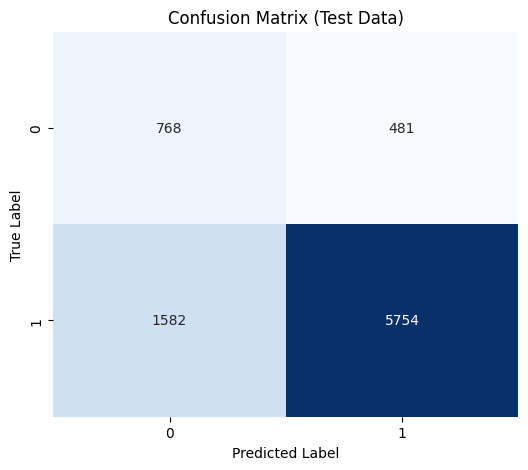

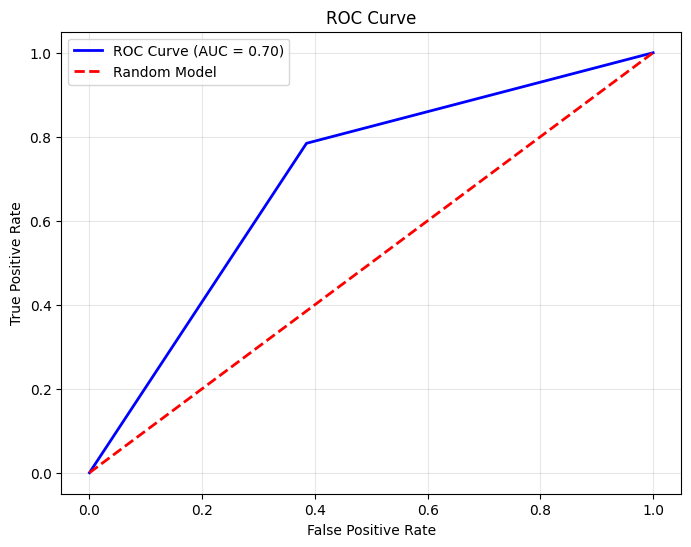

In [ ]:
evaluate_binary_classification(lr3 , xtrain,ytrain_binarized,xtest,ytest_binarized)

Based on the Classification Report for the test data ->
Based on Dissatisfied customers metrics:
1. Out of 100 times, model predicting a dissatisfied customer, 67 times the customer turns out to be of satisfied customer class.
2. Out of 100 times, model predicting a customer as satisfied, 37 times it came out to be dissatisfied. 

Based on satisfied Customer(1) class metrics:
1. Out of 100 times model predicting as satified customer,8 times the customer turns out to be dissatisfied.

Out of 100, model predicting customer as not satified(dissatisfied), 22 times it came out to be satisfied customer.


Note : For Our Problem, We want to correctly detect the dissatisfied customer so that the company can try to connect with them or resolve their satisfaction. So we Want to focus on increasing the Recall(lower FN) for the class 0 (dissatisfied customers). This will our Primary metric to improve.

In [58]:
lr4 = LogisticRegression(max_iter=500 , class_weight='balanced', random_state=42)
lr4.fit(xtrain,ytrain_binarized)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


TRAINING METRICS
Accuracy:  0.7460
Precision: 0.9261
Recall:    0.7637
F1 Score:  0.8371
ROC AUC:   0.7030

TESTING METRICS
Accuracy:  0.7482
Precision: 0.9261
Recall:    0.7665
F1 Score:  0.8388
ROC AUC:   0.7035

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.32      0.64      0.43      1249
           1       0.93      0.77      0.84      7336

    accuracy                           0.75      8585
   macro avg       0.62      0.70      0.63      8585
weighted avg       0.84      0.75      0.78      8585



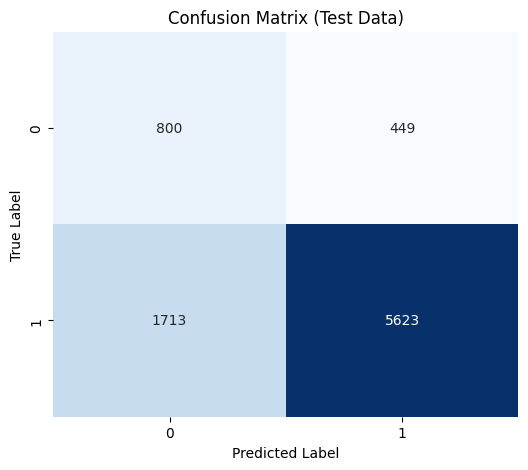

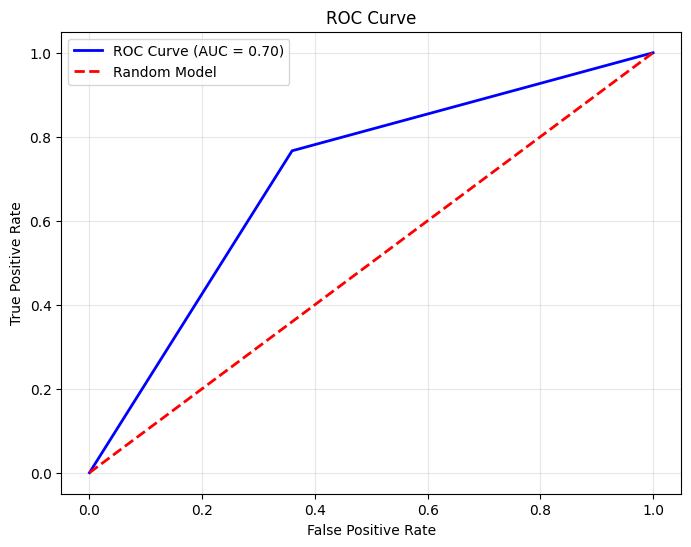

{'test_accuracy': 0.7481654047757716,
 'test_precision': 0.9260540184453228,
 'test_recall': 0.766494002181025,
 'test_f1': 0.8387529832935561,
 'test_roc_auc': 0.7035032060544837}

In [59]:
evaluate_binary_classification(lr4 , xtrain,ytrain_binarized,xtest,ytest_binarized)

In [60]:
lr5 = LogisticRegression(max_iter=1000 , class_weight='balanced', random_state=42 , n_jobs=-1)
lr5.fit(xtrain,ytrain_binarized)




,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


TRAINING METRICS
Accuracy:  0.7460
Precision: 0.9261
Recall:    0.7637
F1 Score:  0.8371
ROC AUC:   0.7030

TESTING METRICS
Accuracy:  0.7482
Precision: 0.9261
Recall:    0.7665
F1 Score:  0.8388
ROC AUC:   0.7035

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.32      0.64      0.43      1249
           1       0.93      0.77      0.84      7336

    accuracy                           0.75      8585
   macro avg       0.62      0.70      0.63      8585
weighted avg       0.84      0.75      0.78      8585



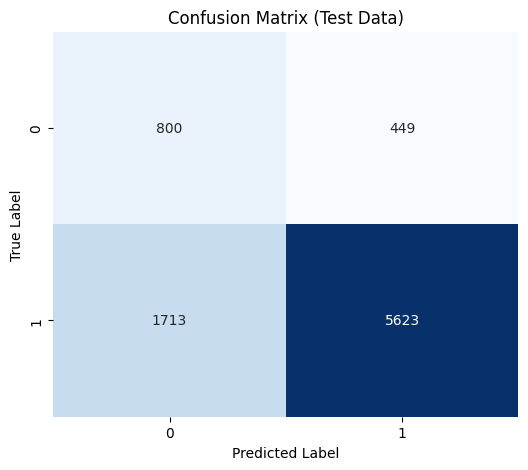

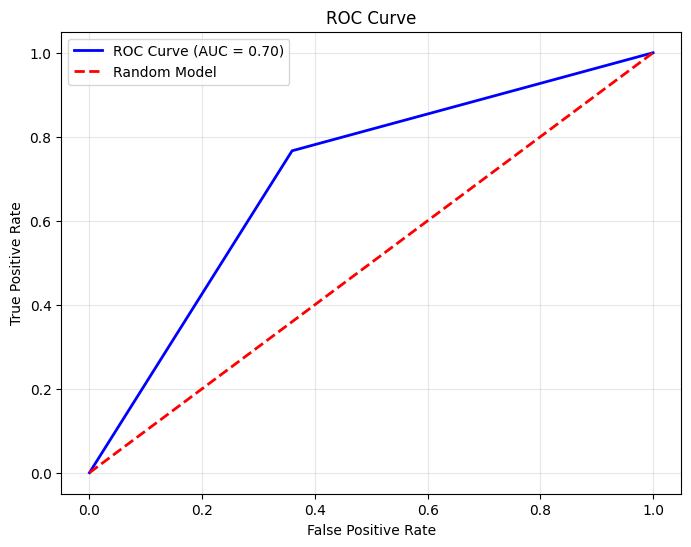

{'test_accuracy': 0.7481654047757716,
 'test_precision': 0.9260540184453228,
 'test_recall': 0.766494002181025,
 'test_f1': 0.8387529832935561,
 'test_roc_auc': 0.7035032060544837}

In [61]:
evaluate_binary_classification(lr5 , xtrain , ytrain_binarized , xtest , ytest_binarized)

Random forest models on binary data

In [62]:
rf4 = RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42 , n_jobs=-1)
rf4.fit(xtrain,ytrain_binarized)


,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


TRAINING METRICS
Accuracy:  0.8705
Precision: 0.8693
Recall:    0.9986
F1 Score:  0.9295
ROC AUC:   0.5587

TESTING METRICS
Accuracy:  0.8688
Precision: 0.8683
Recall:    0.9978
F1 Score:  0.9286
ROC AUC:   0.5546

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.90      0.11      0.20      1249
           1       0.87      1.00      0.93      7336

    accuracy                           0.87      8585
   macro avg       0.88      0.55      0.56      8585
weighted avg       0.87      0.87      0.82      8585



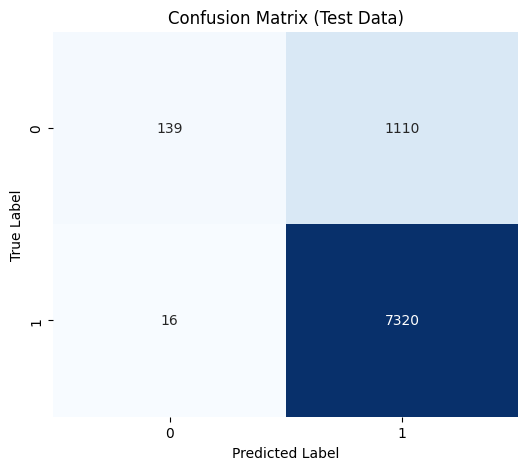

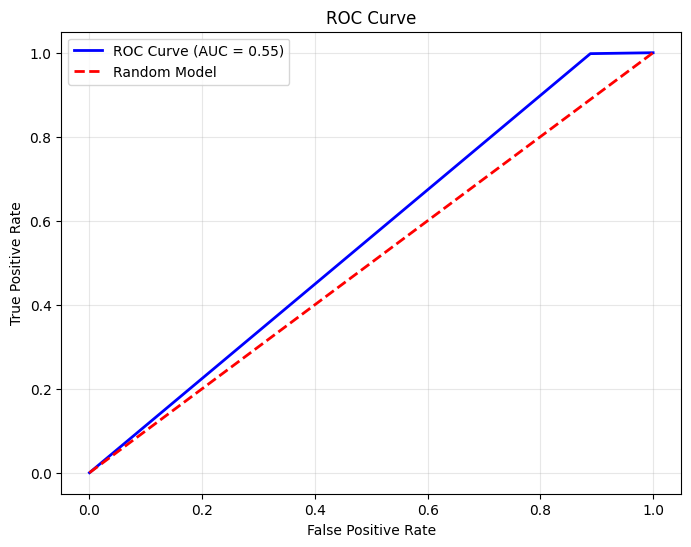

In [63]:

rf4_metrics = evaluate_binary_classification(rf4 , xtrain , ytrain_binarized , xtest , ytest_binarized)

In [64]:
rf5 = RandomForestClassifier(random_state = 42,n_estimators = 200 , max_depth = 10 , class_weight = 'balanced' )

rf5.fit(xtrain,ytrain_binarized)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


TRAINING METRICS
Accuracy:  0.7943
Precision: 0.9292
Recall:    0.8218
F1 Score:  0.8722
ROC AUC:   0.7272

TESTING METRICS
Accuracy:  0.7874
Precision: 0.9265
Recall:    0.8160
F1 Score:  0.8677
ROC AUC:   0.7178

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.36      0.62      0.46      1249
           1       0.93      0.82      0.87      7336

    accuracy                           0.79      8585
   macro avg       0.65      0.72      0.66      8585
weighted avg       0.84      0.79      0.81      8585



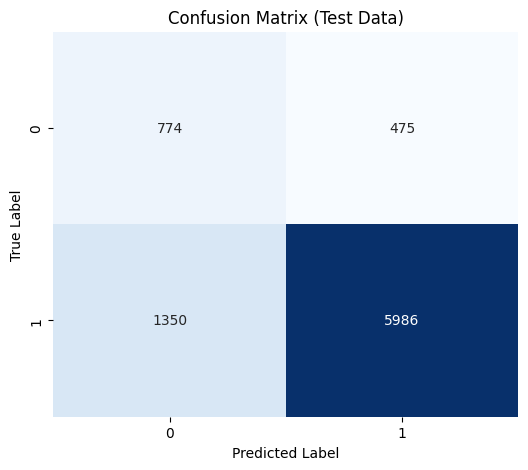

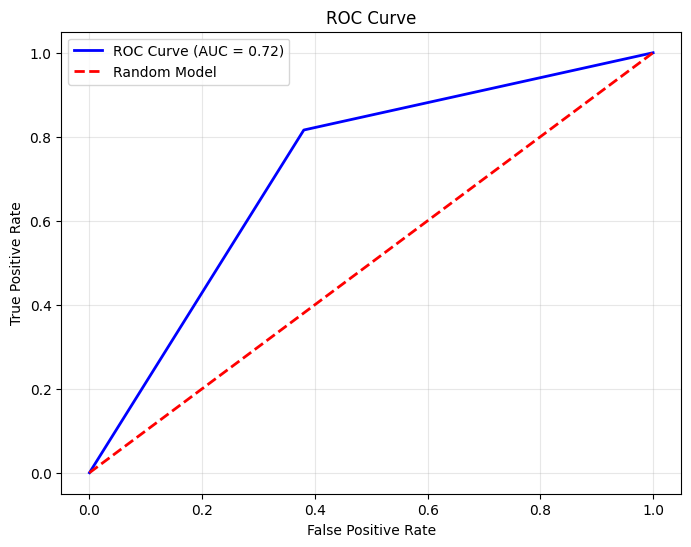

In [ ]:
metrics_rf5 = evaluate_binary_classification(rf5 , xtrain,ytrain_binarized,xtest,ytest_binarized)

In [66]:
rf6 = RandomForestClassifier(random_state = 42,n_jobs=-1 , n_estimators=200 , max_depth=20 , class_weight="balanced")

rf6.fit(xtrain,ytrain_binarized)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


TRAINING METRICS
Accuracy:  0.9142
Precision: 0.9572
Recall:    0.9417
F1 Score:  0.9494
ROC AUC:   0.8473

TESTING METRICS
Accuracy:  0.8376
Precision: 0.9070
Recall:    0.9025
F1 Score:  0.9048
ROC AUC:   0.6795

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.44      0.46      0.45      1249
           1       0.91      0.90      0.90      7336

    accuracy                           0.84      8585
   macro avg       0.68      0.68      0.68      8585
weighted avg       0.84      0.84      0.84      8585



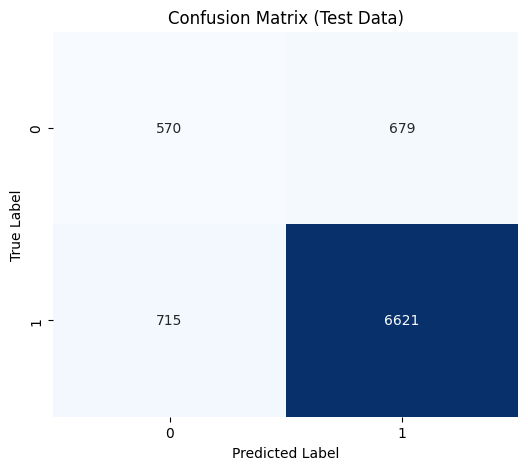

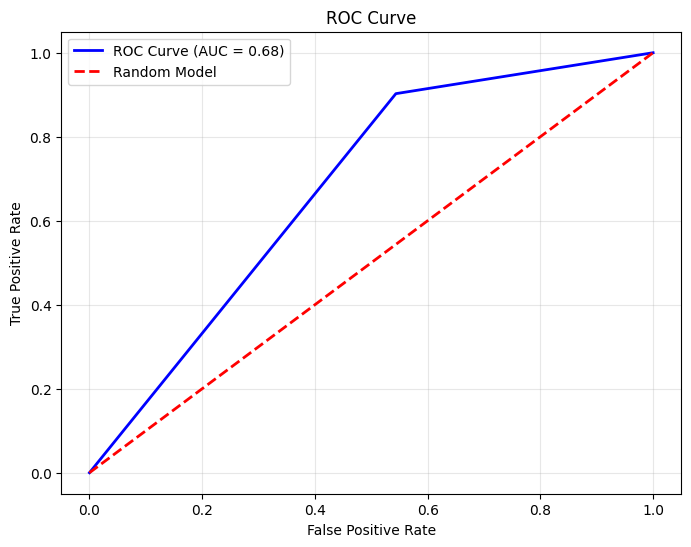

In [67]:
metrics_rf6 = evaluate_binary_classification(rf6 , xtrain,ytrain_binarized,xtest,ytest_binarized)


XGB model

In [68]:
counts = np.unique(ytrain_binarized,return_counts = True)[1]
neg_counts = counts[0]
pos_counts = counts[1]

ratio = neg_counts/pos_counts 

print(neg_counts)
print(pos_counts)
print(ratio)

11246
66018
0.17034748099003302


In [69]:
xgb2 = XGBClassifier(random_state = 42,
                    scale_pos_weight = ratio ,
                    objective = 'binary:logistic',
                    n_estimator = 200 ,
                    max_depth = 20,
                    learning_rate = 0.1,
                    eval_metric = "logloss")

xgb2.fit(xtrain,ytrain_binarized)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


TRAINING METRICS
Accuracy:  0.9244
Precision: 0.9880
Recall:    0.9227
F1 Score:  0.9542
ROC AUC:   0.9284

TESTING METRICS
Accuracy:  0.8123
Precision: 0.9134
Recall:    0.8622
F1 Score:  0.8870
ROC AUC:   0.6909

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.39      0.52      0.45      1249
           1       0.91      0.86      0.89      7336

    accuracy                           0.81      8585
   macro avg       0.65      0.69      0.67      8585
weighted avg       0.84      0.81      0.82      8585



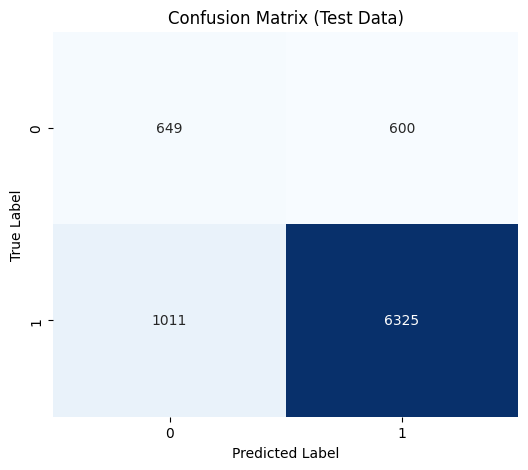

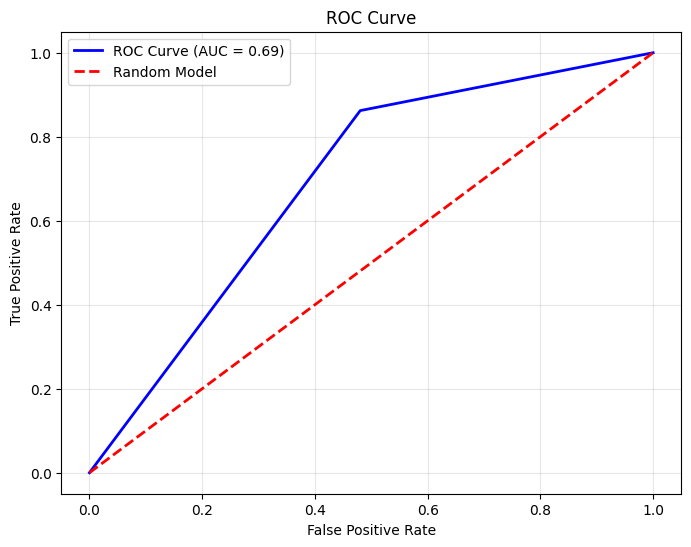

In [70]:
metrics_xgb2 = evaluate_binary_classification(xgb2,xtrain , ytrain_binarized,xtest , ytest_binarized)

### All Models Evaluation:


* Class Definition:

    * Class 0 (Negative): Dissatisfied customers

    * Class 1 (Positive): Satisfied customers



### For our business problem , we would like to find the best balance between Precision and Recall.
    * Recall : Of all dissatisfied customers, how many did we identify?

    * Precision : Of predicted dissatisfied customers, how many are actually dissatisfied?

### Therefore f1score - macro avg seems to be a critical metric.We will choose this metric as our primary evaluation metric for model comparison.


### Best model so far ::

   * Based on the Macro avg f1score metric , rf6 seems to be the best model with f1score of 0.68



In [94]:
joblib.dump(rf6 , f"{models_dir}/rf6.joblib")

['../data_analysis1/artifacts/models/rf6.joblib']

In [ ]:
# saving the best model lr5 

import joblib 
joblib.dump(lr5 , f"{models_dir}/lr5.joblib")




['../data_analysis1/artifacts/models/lr5.joblib']

lr5 model has the highest recall for the class 0 so it is the best model at finding the most dissatisfied customers.Out of 100 dissatisfied customers this model is able to find 64 correctly as dissatisfied.

In [72]:
# Calculating binary class weights

class_counts = np.unique(ytrain_binarized,return_counts=True)
total_counts = len(ytrain_binarized)
class_weights_binary = {cls : round(total_counts/count,2) for cls,count in zip(class_counts[0] , class_counts[1])}
class_weights_binary

{np.int64(0): np.float64(6.87), np.int64(1): np.float64(1.17)}

Now we will try ann models

In [73]:
xtrain.shape , ytrain_binarized.shape , xtest.shape , ytest_binarized.shape

((77264, 139), (77264,), (8585, 139), (8585,))

In [74]:
# ann model 3

ann3 = Sequential()
ann3.add(Input(shape = (xtrain.shape[1],)))

ann3.add(Dense(256 , activation = 'relu'))
ann3.add(Dropout(0.3))

ann3.add(Dense(128, activation='relu',))
ann3.add(Dropout(0.3))

ann3.add(Dense(64, activation='relu',))
ann3.add(Dropout(0.3))

ann3.add(Dense(1, activation = 'sigmoid'))


ann3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 256)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,057 (301.00 KB)

 Trainable params: 77,057 (301.00 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
ann3.compile(optimizer = Adam(learning_rate = 0.1),
             loss = 'binary_crossentropy',
             metrics = ['accuracy']
             )


In [76]:
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.1,
                    patience = 3,
                              mode = 'min',
                              min_lr = 0.0001
                              )

early_stop = EarlyStopping(monitor = 'val_loss',
                           patience = 3,
                           verbose = 1,
                           mode = 'min',
                           restore_best_weights = True)

history1 = ann3.fit(xtrain, ytrain_binarized,
                   validation_data=(xtest, ytest_binarized),
                   epochs=100, 
                   batch_size=32,
             callbacks = [reduce_lr , early_stop])     

Epoch 1/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8534 - loss: 0.4858 - val_accuracy: 0.8545 - val_loss: 0.4211 - learning_rate: 0.1000
Epoch 2/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8544 - loss: 0.6344 - val_accuracy: 0.8545 - val_loss: 0.4190 - learning_rate: 0.1000
Epoch 3/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8544 - loss: 0.5126 - val_accuracy: 0.8545 - val_loss: 0.4153 - learning_rate: 0.1000
Epoch 4/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8544 - loss: 0.4611 - val_accuracy: 0.8545 - val_loss: 0.4153 - learning_rate: 0.1000
Epoch 5/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8544 - loss: 0.4393 - val_accuracy: 0.8545 - val_loss: 0.4155 - learning_rate: 0.1000
Epoch 6/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8544 - loss: 0.5462 - val_accuracy: 0.8545 - val_loss: 0.4148 - learning_rate: 0.1000
Epoch 7/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8

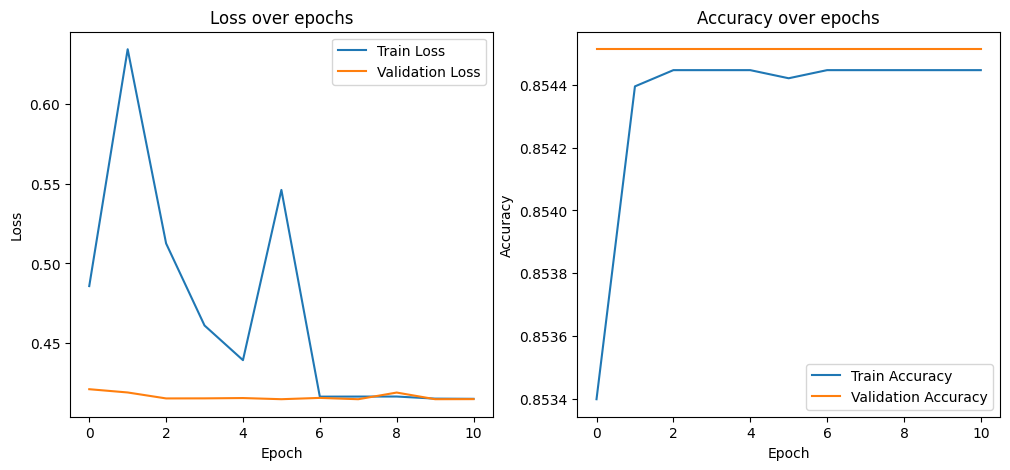

In [77]:
performance_plots(history1)

In [78]:
metrics_eval(ann3 , xtest , ytest_binarized)

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step
F1 Score : 0.1270
Precision: 0.0727
Recall: 0.5000


In [79]:
# Making classification report for ann3


# prediction probabilities
y_test_prob = ann3.predict(xtest).ravel()
# convert to class labels (0 or 1)
y_test_pred = (y_test_prob > 0.5).astype(int)

from sklearn.metrics import classification_report , recall_score 

report = classification_report(ytest_binarized , y_test_pred , target_names=['Dissatisfied (Class 0)', 'Satisfied (Class 1)'])

print(report)

# Get recall for class 0 
recall_class_0 = recall_score(ytest_binarized , y_test_pred , pos_label = 0)
print(f"Recall for class 0 (Dissatisfied): {recall_class_0:.4f}")


269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step
                        precision    recall  f1-score   support

Dissatisfied (Class 0)       0.00      0.00      0.00      1249
   Satisfied (Class 1)       0.85      1.00      0.92      7336

              accuracy                           0.85      8585
             macro avg       0.43      0.50      0.46      8585
          weighted avg       0.73      0.85      0.79      8585

Recall for class 0 (Dissatisfied): 0.0000


ANN4

In [80]:
ann4 = Sequential()
ann4.add(Input(shape = (xtrain.shape[1],)))

ann4.add(Dense(256 , activation = 'relu'))
ann4.add(Dropout(0.3))

ann4.add(Dense(128, activation='relu',))
ann4.add(Dropout(0.3))

ann4.add(Dense(64, activation='relu',))
ann4.add(Dropout(0.3))

ann4.add(Dense(1, activation = 'sigmoid'))


ann4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 256)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,057 (301.00 KB)

 Trainable params: 77,057 (301.00 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
ann4.compile(optimizer = Adam(learning_rate = 0.1),
             loss = 'binary_crossentropy',
             metrics = ['accuracy']
             )

In [82]:
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.1,
                              patience = 3,
                              mode = 'min',
                              min_lr = 0.0001
                              )

early_stop = EarlyStopping(monitor = 'val_loss',
                           patience = 6,
                           verbose = 1,
                           mode = 'min',
                           restore_best_weights = True)

history2 = ann4.fit(xtrain, ytrain_binarized,
                   validation_data=(xtest, ytest_binarized),
                   epochs=100, 
                   batch_size=32,
                   class_weight = class_weights_binary,
             callbacks = [reduce_lr , early_stop])     

Epoch 1/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4748 - loss: 1.5768 - val_accuracy: 0.1455 - val_loss: 0.7155 - learning_rate: 0.1000
Epoch 2/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4950 - loss: 1.3922 - val_accuracy: 0.8545 - val_loss: 0.6746 - learning_rate: 0.1000
Epoch 3/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5054 - loss: 1.3926 - val_accuracy: 0.8545 - val_loss: 0.6554 - learning_rate: 0.1000
Epoch 4/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4968 - loss: 1.3924 - val_accuracy: 0.8545 - val_loss: 0.6860 - learning_rate: 0.1000
Epoch 5/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4844 - loss: 1.3921 - val_accuracy: 0.1455 - val_loss: 0.7000 - learning_rate: 0.1000
Epoch 6/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4961 - loss: 1.3932 - val_accuracy: 0.1455 - val_loss: 0.6954 - learning_rate: 0.1000
Epoch 7/100
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5

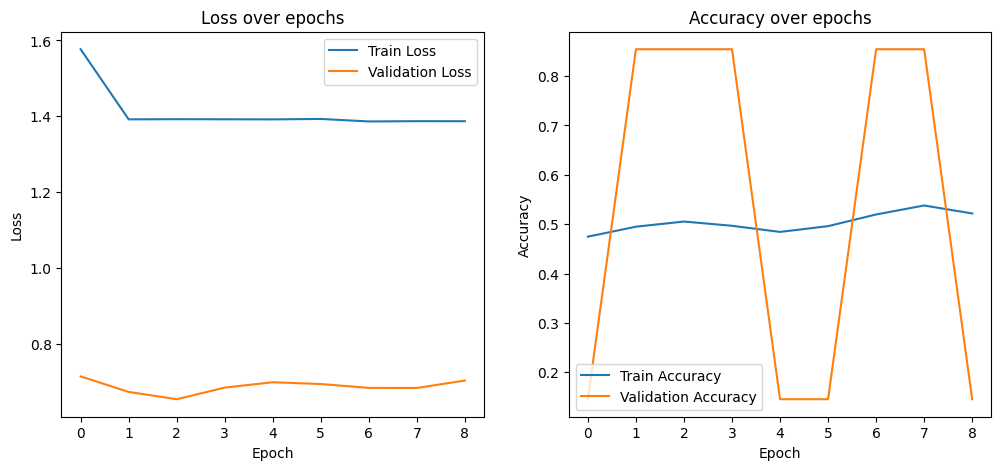

In [83]:
performance_plots(history2)

In [84]:
metrics_eval(ann4 , xtest , ytest_binarized)

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step
F1 Score : 0.1270
Precision: 0.0727
Recall: 0.5000


In [85]:
# Making classification report for ann3


# prediction probabilities
y_test_prob = ann4.predict(xtest).ravel()
# convert to class labels (0 or 1)
y_test_pred = (y_test_prob > 0.5).astype(int)

from sklearn.metrics import classification_report , recall_score 

report = classification_report(ytest_binarized , y_test_pred , target_names=['Dissatisfied (Class 0)', 'Satisfied (Class 1)'])

print(report)


269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step
                        precision    recall  f1-score   support

Dissatisfied (Class 0)       0.00      0.00      0.00      1249
   Satisfied (Class 1)       0.85      1.00      0.92      7336

              accuracy                           0.85      8585
             macro avg       0.43      0.50      0.46      8585
          weighted avg       0.73      0.85      0.79      8585



In [86]:
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

In [87]:
# ANN 5

ann5 = Sequential()
ann5.add(Input(shape=(xtrain.shape[1],)))

# Layer 1
ann5.add(Dense(512, activation='relu'))
ann5.add(BatchNormalization())
ann5.add(Dropout(0.4))

# Layer 2
ann5.add(Dense(256, activation='relu'))
ann5.add(BatchNormalization())
ann5.add(Dropout(0.4))

# Layer 3
ann5.add(Dense(128, activation='relu'))
ann5.add(BatchNormalization())
ann5.add(Dropout(0.3))

# Layer 4
ann5.add(Dense(64, activation='relu'))
ann5.add(BatchNormalization())
ann5.add(Dropout(0.3))

# Layer 5
ann5.add(Dense(32, activation='relu'))
ann5.add(Dropout(0.2))

# Layer 6
ann5.add(Dense(16, activation='relu'))
ann5.add(Dropout(0.2))

# Output layer
ann5.add(Dense(1, activation='sigmoid'))

ann5.summary()

# Compile with LOWER learning rate
ann5.compile(
    optimizer=Adam(learning_rate=0.001),  # Reduced from 0.1 to 0.001
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduced factor (less aggressive)
    patience=5,  # Increased patience
    mode='min',
    min_lr=0.00001
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,  # More patience to allow convergence
    verbose=1,
    mode='min',
    restore_best_weights=True
)

# Train with class weights
history5 = ann5.fit(
    xtrain, ytrain_binarized,
    validation_data=(xtest, ytest_binarized),
    epochs=200,  # Increased epochs
    batch_size=32,
    class_weight=class_weights_binary,  # Critical for class 0
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 512)            │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,625 (979.00 KB)

 Trainable params: 248,705 (971.50 KB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.6900 - loss: 1.2460 - val_accuracy: 0.7768 - val_loss: 0.5388 - learning_rate: 0.0010
Epoch 2/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7542 - loss: 1.1709 - val_accuracy: 0.7923 - val_loss: 0.5267 - learning_rate: 0.0010
Epoch 3/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7530 - loss: 1.1581 - val_accuracy: 0.7724 - val_loss: 0.5544 - learning_rate: 0.0010
Epoch 4/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7587 - loss: 1.1508 - val_accuracy: 0.7981 - val_loss: 0.5537 - learning_rate: 0.0010
Epoch 5/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7616 - loss: 1.1445 - val_accuracy: 0.8128 - val_loss: 0.5241 - learning_rate: 0.0010
Epoch 6/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7615 - loss: 1.1432 - val_accuracy: 0.7917 - val_loss: 0.5250 - learning_rate: 0.0010
Epoch 7/200
2415/2415 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accura

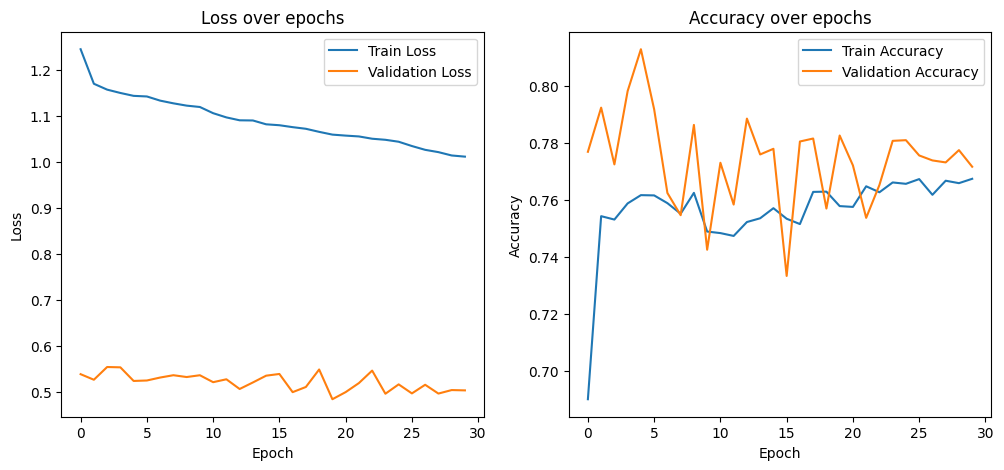

In [88]:
performance_plots(history5)

In [89]:
metrics_eval(ann5 , xtest , ytest_binarized)

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
F1 Score : 0.1270
Precision: 0.0727
Recall: 0.5000


In [90]:
# prediction probabilities
y_test_prob = ann5.predict(xtest).ravel()
# convert to class labels (0 or 1)
y_test_pred = (y_test_prob > 0.5).astype(int)

from sklearn.metrics import classification_report , recall_score 

report = classification_report(ytest_binarized , y_test_pred , target_names=['Dissatisfied (Class 0)', 'Satisfied (Class 1)'])

print(report)

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                        precision    recall  f1-score   support

Dissatisfied (Class 0)       0.35      0.61      0.45      1249
   Satisfied (Class 1)       0.92      0.81      0.86      7336

              accuracy                           0.78      8585
             macro avg       0.64      0.71      0.66      8585
          weighted avg       0.84      0.78      0.80      8585



This ann5 model has performed the best compared to other two previous ann models. This is able to predict dissatisfied class with atleast comparable performance to our some of the best models so far. The recall for the class 0 is 0.61 here. THe best model lr5 has the recall of 0.64. 

In [92]:
# saving the ann5 model

ann5.save(f"{models_dir}/ann5_model.keras")

| Model                         |   Test Accuracy | Test Precision (overall shown) | Test Recall (overall shown) | Test F1 (overall shown) |    ROC AUC (test) | Macro-avg F1 (from reports) |
| ----------------------------- | --------------: | -----------------------------: | --------------------------: | ----------------------: | ----------------: | --------------------------: |
| **lr5 (Logistic Regression)** |          0.7482 |                         0.9261 |                      0.7665 |                  0.8388 |            0.7035 |                        0.63 |
| **rf5 (Random Forest 5)**     |          0.7874 |                         0.9265 |                      0.8160 |                  0.8677 |            0.7178 |                        0.66 |
| **rf6 (Random Forest 6)**     |          0.8376 |                         0.9070 |                      0.9025 |                  0.9048 |            0.6795 |                        0.68 |
| **ann5 (ANN)**                | 0.78 (reported) |              — per-class shown |           — per-class shown |       — per-class shown | (no AUC reported) |    0.66 (macro from report) |


All the above mentioned models in the table are performing the best for our case but based on the final metric Recall for Class 0 to find the most dissatisfied customers - lr5 is the best scorer with 0.64 as recall score. We will take it as the best model.

MODEL TRAINING COMPLETED 

Trying smote for making the data balanced and using the vif reduced dataset

In [12]:
xtrain ,  xtest ,ytrain ,ytest = train_test_split(X_reduced_1, y , test_size = 0.1 , stratify = y , random_state=42)
xtrain.shape , ytrain.shape , xtest.shape , ytest.shape

((77264, 65), (77264,), (8585, 65), (8585,))

In [14]:
# i have x_reduced_1 and y and i want to balance y to make all the 5 classes equal using smotetomek

from imblearn.combine import SMOTETomek

smotetomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smotetomek.fit_resample(xtrain, ytrain)
print("Original class distribution:", np.unique(ytrain, return_counts=True))
print("Resampled class distribution:", np.unique(y_resampled, return_counts=True))



Original class distribution: (array([1, 2, 3, 4, 5]), array([10092,  1154,  2301, 10089, 53628]))
Resampled class distribution: (array([1, 2, 3, 4, 5]), array([53122, 53343, 53288, 52930, 52687]))


In [15]:
log_reg = LogisticRegression(random_state=42, class_weight='balanced' , n_jobs=-1)
log_reg.fit(xtrain, ytrain)
print(log_reg.score(xtrain, ytrain))
print(log_reg.score(xtest, ytest))

0.44023089666597637
0.43937099592312173


Training Metrics:
Accuracy: 0.4402
Precision: 0.2842
Recall: 0.2879
F1 Score: 0.2624
ROC AUC: 0.6265

Testing Metrics:
Accuracy: 0.4394
Precision: 0.2838
Recall: 0.2853
F1 Score: 0.2605
ROC AUC: 0.6222

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.42      0.38      0.40      1121
           2       0.02      0.02      0.02       128
           3       0.04      0.16      0.07       256
           4       0.16      0.38      0.22      1121
           5       0.79      0.48      0.60      5959

    accuracy                           0.44      8585
   macro avg       0.28      0.29      0.26      8585
weighted avg       0.62      0.44      0.50      8585



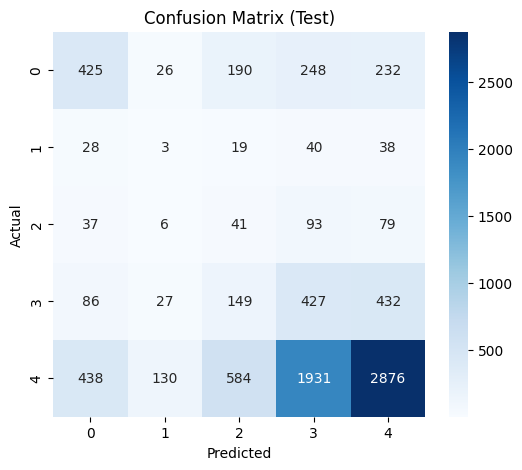

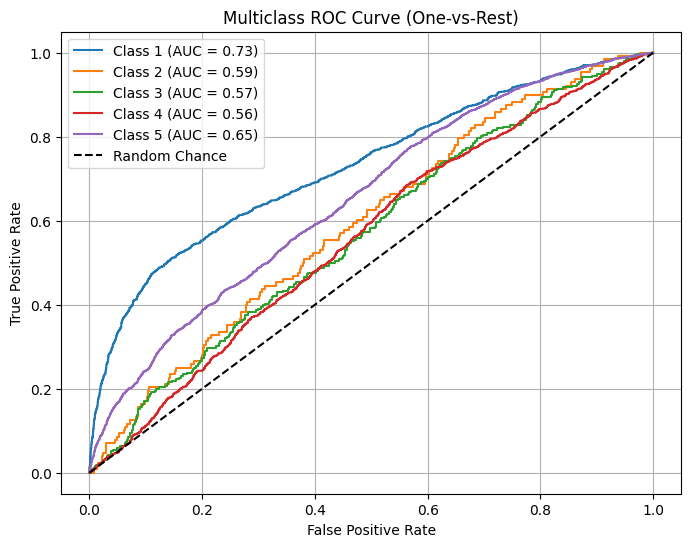

In [16]:
# evaluate metrics for log_reg
log_reg_train_metrics, log_reg_test_metrics = evaluate_classification_model1(log_reg, xtrain, ytrain, xtest, ytest)


In [17]:
# ran_for
ran_for = RandomForestClassifier(random_state = 42,n_jobs=-1 , n_estimators=200 , max_depth=20 , class_weight="balanced")

ran_for.fit(xtrain,ytrain)

print(ran_for.score(xtrain,ytrain))
print(ran_for.score(xtest,ytest))

0.8651377096707393
0.6115317414094351


Training Metrics:
Accuracy: 0.8651
Precision: 0.7402
Recall: 0.8664
F1 Score: 0.7920
ROC AUC: 0.9595

Testing Metrics:
Accuracy: 0.6115
Precision: 0.2929
Recall: 0.2894
F1 Score: 0.2910
ROC AUC: 0.6285

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.45      0.44      0.44      1121
           2       0.05      0.04      0.04       128
           3       0.04      0.04      0.04       256
           4       0.17      0.16      0.17      1121
           5       0.75      0.77      0.76      5959

    accuracy                           0.61      8585
   macro avg       0.29      0.29      0.29      8585
weighted avg       0.61      0.61      0.61      8585



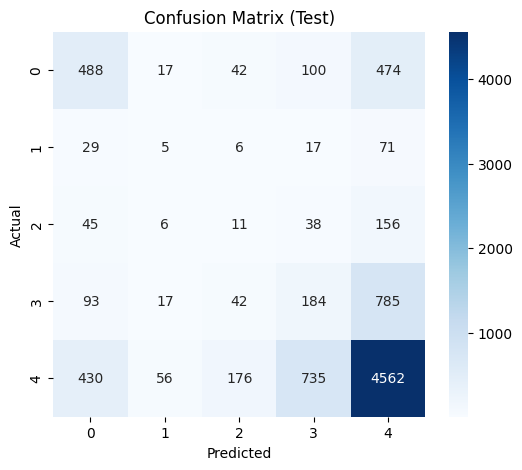

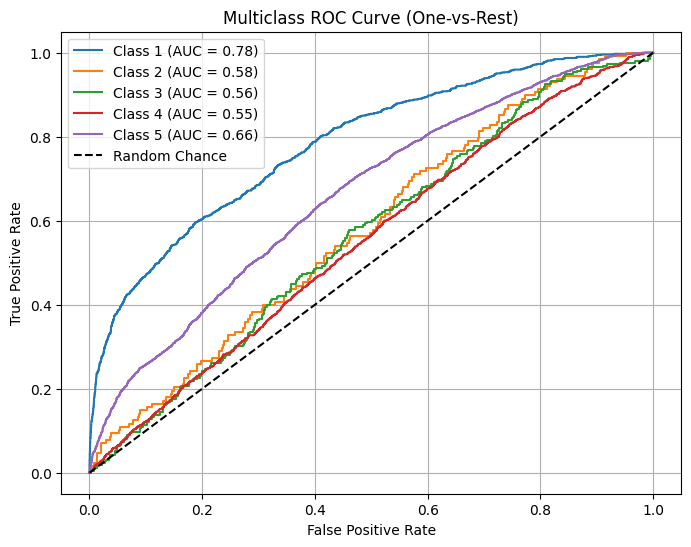

In [18]:
# evaluate 
ran_for_train_metrics, ran_for_test_metrics = evaluate_classification_model1(ran_for, xtrain, ytrain, xtest, ytest)

In [ ]:
# ann_new
ann4 = Sequential()
ann4.add(Input(shape = (xtrain.shape[1],)))

ann4.add(Dense(256 , activation = 'relu'))
ann4.add(Dropout(0.3))

ann4.add(Dense(128, activation='relu',))
ann4.add(Dropout(0.3))

ann4.add(Dense(64, activation='relu',))
ann4.add(Dropout(0.3))

ann4.add(Dense(1, activation = 'sigmoid'))


ann4.summary()

In [ ]:
ann4.compile(optimizer = Adam(learning_rate = 0.1),
             loss = 'binary_crossentropy',
             metrics = ['accuracy']
             )

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.1,
                              patience = 3,
                              mode = 'min',
                              min_lr = 0.0001
                              )

early_stop = EarlyStopping(monitor = 'val_loss',
                           patience = 6,
                           verbose = 1,
                           mode = 'min',
                           restore_best_weights = True)

history2 = ann4.fit(xtrain, ytrain_binarized,
                   validation_data=(xtest, ytest_binarized),
                   epochs=100, 
                   batch_size=32,
                   class_weight = class_weights_binary,
             callbacks = [reduce_lr , early_stop])     

In [ ]:
performance_plots(history2)

In [ ]:
metrics_eval(ann4 , xtest , ytest_binarized)